# S&P 500 Value Analyzer

## Project Goal

The goal of this project is to understand what an investor is actually buying when they buy the S&P 500.

This notebook will start by loading the current S&P 500 company list, cleaning the data, and exploring the companies by sector, industry, and company age.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:

import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

sp500 = tables[0]

sp500.head(30)-++

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
5,ADBE,Adobe Inc.,Information Technology,Application Software,"San Jose, California",1997-05-05,796343,1982
6,AMD,Advanced Micro Devices,Information Technology,Semiconductors,"Santa Clara, California",2017-03-20,2488,1969
7,AES,AES Corporation,Utilities,Independent Power Producers & Energy Traders,"Arlington, Virginia",1998-10-02,874761,1981
8,AFL,Aflac,Financials,Life & Health Insurance,"Columbus, Georgia",1999-05-28,4977,1955
9,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,"Santa Clara, California",2000-06-05,1090872,1999


## Step 1: Understand the Raw S&P 500 Dataset

Before cleaning or analyzing the data, I inspected the dataset to understand what information it contains.

This step checks:

- The number of rows and columns
- The column names
- The data types
- Whether any values are missing

This is important because data should be understood before it is cleaned or used for analysis.

In [40]:
sp500.shape
sp500.info()
sp500.describe()
sp500.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Symbol                 503 non-null    str  
 1   Security               503 non-null    str  
 2   GICS Sector            503 non-null    str  
 3   GICS Sub-Industry      503 non-null    str  
 4   Headquarters Location  503 non-null    str  
 5   Date added             503 non-null    str  
 6   CIK                    503 non-null    int64
 7   Founded                503 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.6 KB


Symbol                   0
Security                 0
GICS Sector              0
GICS Sub-Industry        0
Headquarters Location    0
Date added               0
CIK                      0
Founded                  0
dtype: int64

### Initial Data Check

- The dataset has no null values.
- Most columns are stored as `str`, which usually means text or mixed text values.
- The `CIK` column is stored as `int64`.
- Some columns need to be converted before analysis:
  - `Date added` should become a datetime column.
  - `Founded` should be cleaned into a numeric founded year.

## Step 2: Convert Date Added to Datetime

The `Date added` column looks like a date, but it needs to be converted into a datetime format so it can be used for time-based analysis.

In [41]:
sp500["Date added"] = pd.to_datetime(sp500["Date added"], errors="coerce")

sp500[["Symbol", "Security", "Date added"]].head()

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06


In [42]:
sp500["Date added"].dtype

dtype('<M8[us]')

In [43]:
sp500["Date added"].isna().sum()

np.int64(0)

### Data type change 

- The dataset has no null values.
- the `Date Added` column has changed to `datetime64`
- Some columns need to be converted before analysis:
  - `Founded` should be cleaned into a numeric founded year.

## Step 3: Convert Founded Year to a Number

The original `Founded` column is stored as text and sometimes contains extra information. Instead of changing the original column, I will create a new cleaned column called `Founded Year`.

This new column will contain only the four-digit founded year as a number, which can later be used to calculate company age.

In [44]:
sp500['Founded year'] = sp500['Founded'].str.extract(r'(\d{4})').astype(float)

In [45]:
sp500["Founded year"].head()

0    1902.0
1    1916.0
2    1888.0
3    2013.0
4    1989.0
Name: Founded year, dtype: float64

In [46]:
sp500["Founded year"].dtype

dtype('float64')

In [47]:
sp500["Founded year"].isna().sum()

np.int64(0)

### Data type change 

- The dataset has no null values.
- the `founded` column has changed to `float64`

## Step 4: Calculate Company Age

After creating a numeric founded year column, I calculated each company’s approximate age.

This helps answer how old the companies inside the S&P 500 are.

In [48]:
from datetime import datetime

In [49]:
sp500['Company age'] = datetime.now().year - sp500['Founded year']
sp500[['Symbol', 'Security','Founded', 'Founded year', 'Company age']].head()

,Symbol,Security,Founded,Founded year,Company age
0,MMM,3M,1902,1902.0,124.0
1,AOS,A. O. Smith,1916,1916.0,110.0
2,ABT,Abbott Laboratories,1888,1888.0,138.0
3,ABBV,AbbVie,2013 (1888),2013.0,13.0
4,ACN,Accenture,1989,1989.0,37.0


### Observation

The `Company age` column was created using the current year and the cleaned `Founded year` column.

This new column can now be used to analyze the age distribution of companies in the S&P 500.

## Step 5: Sector Distribution by Company Count

I will count how many companies belong to each GICS sector.

This gives an initial view of what types of businesses are represented in the S&P 500. This is different from index weight because each company does not represent the same percentage of the index.

In [50]:
sp500['GICS Sector'].value_counts()

GICS Sector
Industrials               79
Financials                76
Information Technology    73
Health Care               58
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64

### Observation

The sector count shows how many companies belong to each sector in the S&P 500.

This helps show the variety of companies in the index, but it does not show how much weight each sector has in the index. A sector can have fewer companies but still represent a large part of the S&P 500 if those companies are very large.

## Step 6: Visualize Sector Distribution

After counting the number of companies in each sector, I created a bar chart to make the sector distribution easier to compare visually.

This chart shows the S&P 500 by company count, not by market-cap weight.

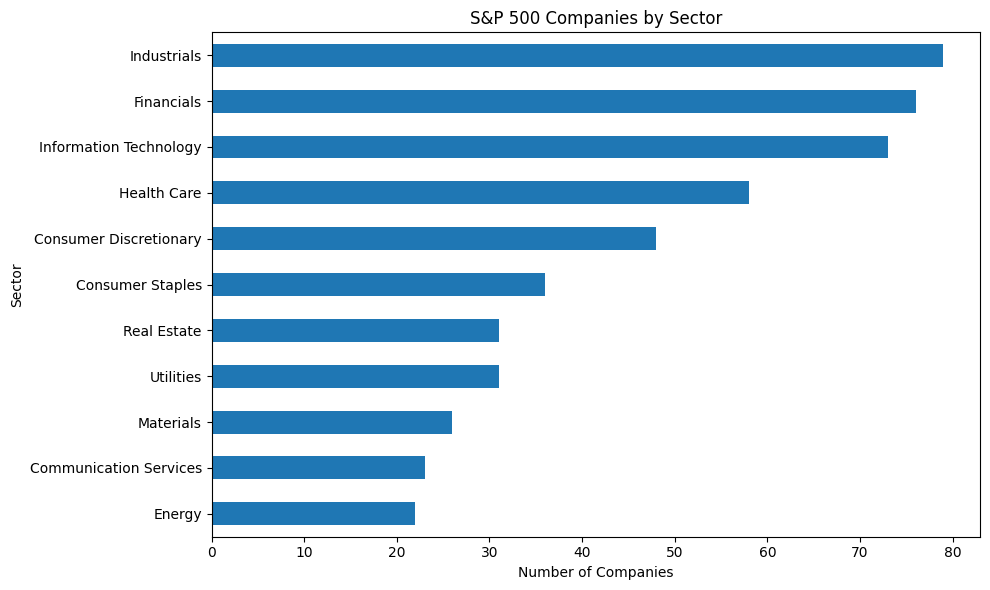

In [51]:
sector_counts = sp500["GICS Sector"].value_counts()
sector_counts.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("S&P 500 Companies by Sector")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

### Observation

Industrials, Financials, and Information Technology have the highest number of companies in the S&P 500 by count.

However, this does not mean they have the highest weight in the index. The S&P 500 is market-cap weighted, so larger companies have more influence than smaller companies.

## Step 7: Sub-Industry Distribution

After looking at broad sectors, I analyzed the GICS sub-industries to get a more detailed view of the types of businesses inside the S&P 500.

This helps show whether the index is concentrated in specific business types, not just broad sectors.

In [52]:
sp500['GICS Sub-Industry'].value_counts()

GICS Sub-Industry
Health Care Equipment                           16
Application Software                            15
Electric Utilities                              15
Semiconductors                                  14
Industrial Machinery & Supplies & Components    14
                                                ..
Health Care Technology                           1
Food Distributors                                1
Passenger Ground Transportation                  1
Timber REITs                                     1
Homefurnishing Retail                            1
Name: count, Length: 127, dtype: int64

### Observation

The sub-industry count gives a more detailed view of what types of companies are in the S&P 500.

This is still based on company count, not index weight. A sub-industry with fewer companies may still represent a large part of the index if those companies have very large market capitalizations.

## Step 8: Visualize the Top Sub-Industries

The S&P 500 contains many different sub-industries, so I focused on the top 15 by company count.

This makes the chart easier to read while still showing which business types appear most often in the index.

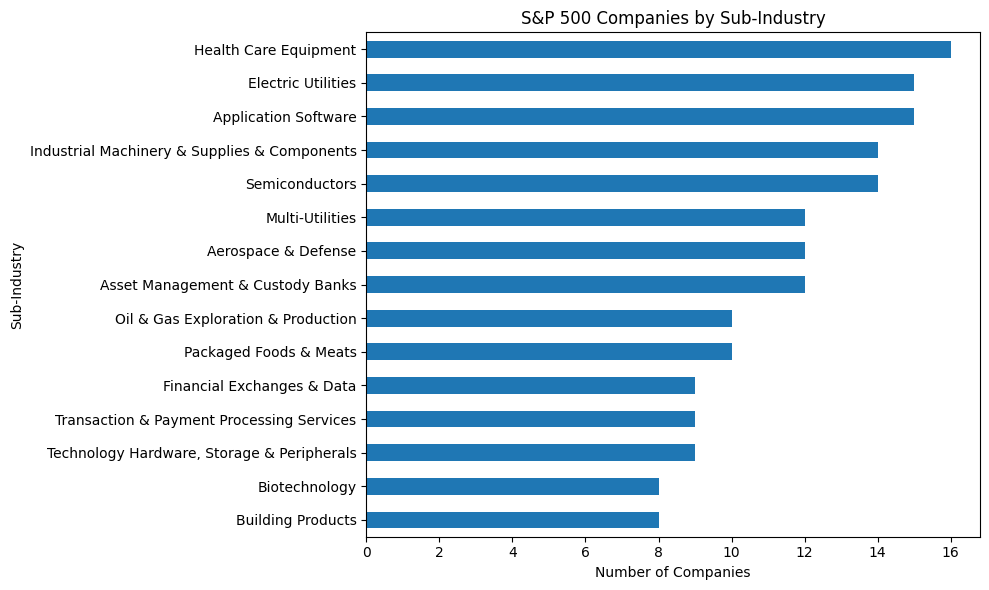

In [53]:
sub_industry_counts = sp500["GICS Sub-Industry"].value_counts()
top_15_sub_industries = sub_industry_counts.head(15)

top_15_sub_industries.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("S&P 500 Companies by Sub-Industry")
plt.xlabel("Number of Companies")
plt.ylabel("Sub-Industry")
plt.tight_layout()
plt.show()

### Note

There are many different sub-industries in the S&P 500, so I selected only the top 15 by company count. This makes the result easier to read and visualize.

## Step 9: Company Age Analysis

After calculating company age, I analyzed the age distribution of companies in the S&P 500.

This helps show whether the index is mostly made up of older established companies, newer companies, or a mix of both.

In [54]:
sp500['Company age'].describe()

count    503.000000
mean      68.741551
std       48.926410
min        1.000000
25%       31.000000
50%       55.000000
75%      103.000000
max      242.000000
Name: Company age, dtype: float64

In [55]:
sp500 = sp500.sort_values(by='Company age', ascending=True)
sp500[['Symbol', 'Security', 'Founded', 'Company age']].head()

,Symbol,Security,Founded,Company age
359,PSKY,Paramount Skydance Corporation,2025 (Paramount Pictures 1912),1.0
386,Q,Qnity Electronics,2025,1.0
215,GEV,GE Vernova,2024,2.0
445,TKO,TKO Group Holdings,2023,3.0
467,VLTO,Veralto,2023,3.0


### Observation

The company age analysis shows the range of company ages inside the S&P 500. Some companies are over 100 years old, while others are much newer.

This shows that the S&P 500 includes both long-established businesses and newer companies that have grown large enough to be included in the index.

## Step 10: Visualize Company Age Distribution

After calculating company age, I created a histogram to see how company ages are distributed across the S&P 500.

This helps show whether the index is mostly made up of older established companies, newer companies, or a mix of both.

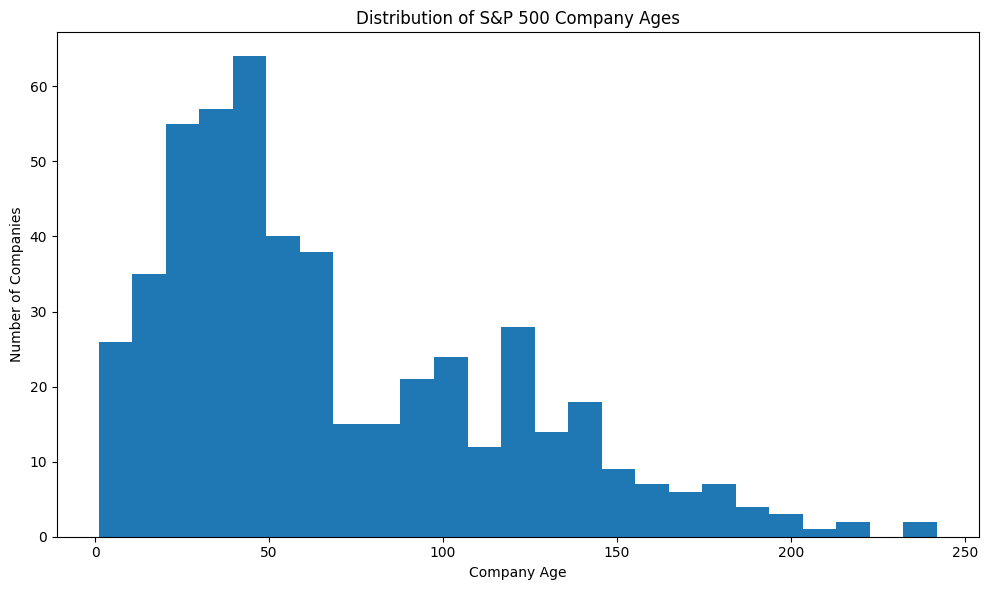

In [56]:
ages = sp500["Company age"]

plt.figure(figsize=(10, 6))
plt.hist(ages, bins=25)

plt.title("Distribution of S&P 500 Company Ages")
plt.xlabel("Company Age")
plt.ylabel("Number of Companies")

plt.tight_layout()
plt.show()

### Observation

The histogram shows that the S&P 500 includes companies with a wide range of ages.

There appears to be an inclination toward companies around the 30 to 50 year age range. This suggests that many companies in the index are established businesses, but not necessarily extremely old companies.

The index also includes much older companies that are over 100 years old, as well as newer companies that became large enough to be included.

## Step 11: Test Financial Data Collection

The earlier sections analyzed the S&P 500 company list using basic company information such as sector, sub-industry, and company age.

The next part of the project collects financial data. I will start by testing one company first to understand the yfinance syntax and check which financial fields are available.

In [57]:
import yfinance as yf

In [58]:
apple = yf.Ticker("AAPL")
apple_info = apple.info
apple_info.get("marketCap")

4110619508736

In [59]:
apple_info.get("priceToBook")

46.723907

In [60]:
apple_info.get("trailingPE")

33.92857

In [61]:
apple_info.get("forwardPE")

29.304062

In [62]:
apple_info.get("dividendYield")

0.39

### Observation

The yfinance test successfully returned Apple’s market capitalization and several valuation metrics.

This confirms that yfinance can provide financial data that may help estimate company size, valuation, and income characteristics for the S&P 500 analysis.

## Step 12: Create a Financial Data Table for One Company

After testing individual yfinance fields, I organized the selected financial values into a small table.

This makes the data easier to inspect and prepares the project for collecting the same fields from multiple companies.

In [63]:
apple_record = {
    "Symbol": "AAPL",
    "Market Cap": apple_info.get("marketCap"),
    "Price to Book": apple_info.get("priceToBook"),
    "Trailing P/E": apple_info.get("trailingPE"),
    "Forward P/E": apple_info.get("forwardPE"),
    "Dividend Yield": apple_info.get("dividendYield")
}


In [64]:
apple_financials = pd.DataFrame([apple_record])
apple_financials.head()

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,AAPL,4110619508736,46.723907,33.92857,29.304062,0.39


### Observation

The selected yfinance fields were organized into a one-row DataFrame for Apple.

This structure can be reused later to collect the same financial data for multiple S&P 500 companies.

## Step 13: Test Financial Data Collection with Multiple Companies

After testing yfinance with one company, I repeated the process with a small list of companies.

This helps confirm that the same financial fields can be collected consistently across multiple tickers before scaling the process to the full S&P 500.

In [65]:
test_symbols = ["AAPL", "MSFT", "NVDA"]

financial_records = []

for symbol in test_symbols:
    ticker = yf.Ticker(symbol)
    info = ticker.info

    record = {
        "Symbol": symbol,
        "Market Cap": info.get("marketCap"),
        "Price to Book": info.get("priceToBook"),
        "Trailing P/E": info.get("trailingPE"),
        "Forward P/E": info.get("forwardPE"),
        "Dividend Yield": info.get("dividendYield")
    }

    financial_records.append(record)

test_financials = pd.DataFrame(financial_records)

test_financials

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,AAPL,4110619508736,46.723907,33.92857,29.304062,0.39
1,MSFT,3076820566016,7.872185,24.68385,21.439354,0.88
2,NVDA,4823327440896,30.662855,40.50000,17.656982,0.02


### Observation

The loop successfully collected financial data for multiple companies and stored the results in a pandas DataFrame.

This confirms that the project can repeat the yfinance collection process across a list of tickers. The next step is to prepare the S&P 500 ticker symbols so they can be used with yfinance.

## Step 14: Prepare Tickers for yfinance

The original S&P 500 dataset includes a `Symbol` column. Some tickers use periods, but yfinance often uses dashes instead.

I created a new column called `YF Symbol` so the project can keep the original ticker symbols while also having a version formatted for yfinance.

In [66]:
sp500["YF Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)
sp500[["Symbol", "YF Symbol", "Security"]].head(30)

,Symbol,YF Symbol,Security
359,PSKY,PSKY,Paramount Skydance Corporation
386,Q,Q,Qnity Electronics
215,GEV,GEV,GE Vernova
445,TKO,TKO,TKO Group Holdings
467,VLTO,VLTO,Veralto
417,SOLV,SOLV,Solventum
271,KVUE,KVUE,Kenvue
483,WBD,WBD,Warner Bros. Discovery
134,CTRA,CTRA,Coterra
87,CARR,CARR,Carrier Global


In [67]:
sp500[sp500["Symbol"] != sp500["YF Symbol"]][["Symbol", "YF Symbol", "Security"]]

,Symbol,YF Symbol,Security
76,BF.B,BF-B,Brown–Forman
61,BRK.B,BRK-B,Berkshire Hathaway


### Observation

A new column called `YF Symbol` was created for yfinance-compatible ticker symbols.

Most tickers stayed the same because they do not contain periods. However, this step is important because some S&P 500 tickers use periods in the original `Symbol` column, while yfinance often expects dashes instead.

Keeping both columns is useful because `Symbol` preserves the original ticker from the S&P 500 dataset, while `YF Symbol` can be used later to collect financial data with yfinance.

## Step 15: Create the S&P 500 Symbol List

After creating the `YF Symbol` column, I converted it into a Python list.

This list will be used in the financial data collection loop so yfinance can collect data for each company one ticker at a time.

In [68]:
sp500_symbols = sp500["YF Symbol"].tolist()

sp500_symbols[:10]

['PSKY', 'Q', 'GEV', 'TKO', 'VLTO', 'SOLV', 'KVUE', 'WBD', 'CTRA', 'CARR']

In [69]:
len(sp500_symbols)

503

### Observation

The `YF Symbol` column was converted into a Python list for financial data collection.

The number of symbols in the list matches the number of rows in the S&P 500 dataset, which means each row has a ticker symbol ready for the yfinance loop.

## Step 16: Collect Financial Data with yfinance

Using the S&P 500 symbol list, I collected financial data for each company with yfinance.

The goal of this step is to collect valuation-related fields such as market capitalization, price-to-book ratio, P/E ratios, and dividend yield. These fields will be used later to estimate index weights and compare valuation across companies and sectors.

Because financial data can sometimes be missing or unavailable, this step should be checked carefully before using the data for analysis.

In [ ]:
financial_records = []

for symbol in sp500_symbols:
    ticker = yf.Ticker(symbol)
    info = ticker.info

    record = {
        "Symbol": symbol,
        "Market Cap": info.get("marketCap"),
        "Price to Book": info.get("priceToBook"),
        "Trailing P/E": info.get("trailingPE"),
        "Forward P/E": info.get("forwardPE"),
        "Dividend Yield": info.get("dividendYield")
    }

    financial_records.append(record)
    print(f"Processed {symbol}")
full_financials = pd.DataFrame(financial_records)

full_financials.head(10)

Processed PSKY
Processed Q
Processed GEV
Processed TKO
Processed VLTO
Processed SOLV
Processed KVUE
Processed WBD
Processed CTRA
Processed CARR
Processed OTIS
Processed AMCR
Processed FOX
Processed DOW
Processed FOXA
Processed LHX
Processed CTVA
Processed BKR
Processed TPR
Processed DD
Processed VICI
Processed VRT
Processed DELL
Processed VST
Processed WTW
Processed FTV
Processed KHC
Processed LITE
Processed HPE
Processed ELV
Processed KEYS
Processed NWS
Processed ABBV
Processed NWSA
Processed HOOD
Processed COIN
Processed INVH
Processed CVNA
Processed MNST
Processed MDLZ
Processed PSX
Processed DASH
Processed APP
Processed HII
Processed NCLH
Processed CRWD
Processed XYL
Processed MRNA
Processed LYV
Processed DDOG
Processed MPC
Processed UBER
Processed XYZ
Processed TTD
Processed SATS
Processed ABNB
Processed PM
Processed FANG
Processed LYB
Processed TEL
Processed TMO
Processed PANW
Processed TAP
Processed TRGP
Processed WDAY
Processed DLR
Processed ANET
Processed META
Processed MOS
Pr

,Symbol,Market Cap,Price to Book,Trailing P/E,Forward P/E,Dividend Yield
0,PSKY,12329208832,1.066039,369.666700,12.061690,1.80
1,Q,30050412544,4.233018,43.433334,32.664085,0.22
2,GEV,285635903488,20.516705,31.053170,43.879982,0.14
3,TKO,13940238336,3.869203,81.916300,46.781403,1.68
4,VLTO,21521862656,7.162240,22.585050,18.874792,0.59
5,SOLV,11559838720,2.289533,7.503378,9.552483,NaN
6,KVUE,33464141824,3.102528,22.934212,14.537600,4.76
7,WBD,67607539712,1.862183,93.000000,-1541.142800,NaN
8,CTRA,26866036736,1.812129,15.794643,11.963373,2.49
9,CARR,56163848192,4.197393,45.080000,21.157036,1.42


### Observation

The financial data collection loop created a DataFrame with valuation-related data for S&P 500 companies.

This dataset includes market capitalization and valuation metrics that can be used in later analysis. Since yfinance data may have missing values for some companies, the next step is to inspect missing data before calculating weights or valuation ratios.